In [1]:
import numpy as np
import pandas as pd
import seaborn as sns


In [3]:
# load data
final_degree_histograms = pd.read_csv('data/final_degree_histograms.csv')
infected_timeseries = pd.read_csv('data/infected_timeseries.csv')
rewiring_timeseries = pd.read_csv('data/rewiring_timeseries.csv')

<Axes: xlabel='time', ylabel='infected_fraction'>

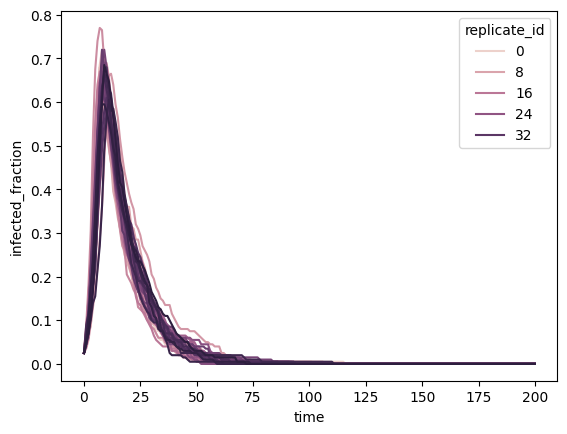

In [ ]:
# plot replicates of the infected_timeseries
sns.lineplot(data=infected_timeseries, x='time', y='infected_fraction', hue='replicate_id')

In [14]:
def peak_infection_fraction(df):
    return df.loc[df['infected_fraction'].idxmax(), 'infected_fraction']

def peak_infection_time(df):
    return df.loc[df['infected_fraction'].idxmax(), 'time']

peak_infection_fractions = infected_timeseries.groupby('replicate_id').apply(peak_infection_fraction)
peak_infection_times = infected_timeseries.groupby('replicate_id').apply(peak_infection_time)

In [23]:
peak_infection_fractions.describe()

count    40.000000
mean      0.657125
std       0.042666
min       0.540000
25%       0.633750
50%       0.662500
75%       0.681250
max       0.770000
dtype: float64

In [24]:
peak_infection_times.describe()

count    40.000000
mean      8.750000
std       1.192928
min       7.000000
25%       8.000000
50%       8.500000
75%       9.000000
max      12.000000
dtype: float64

<Axes: xlabel='time', ylabel='rewire_count'>

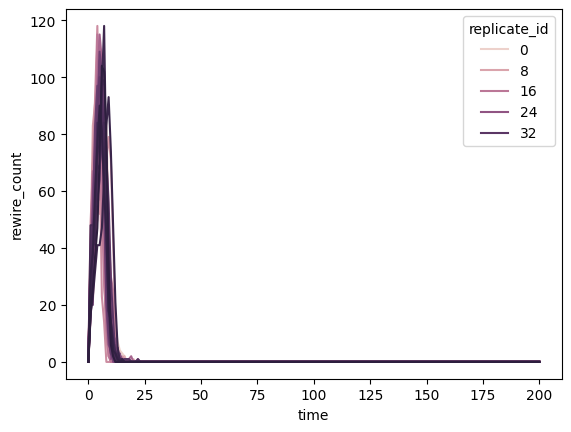

In [21]:
# plot replicates of the rewiring_timeseries
sns.lineplot(data=rewiring_timeseries, x='time', y='rewire_count', hue='replicate_id')

In [22]:
def peak_rewire_count(df):
    return df.loc[df['rewire_count'].idxmax(), 'rewire_count']

def peak_rewire_count_time(df):
    return df.loc[df['rewire_count'].idxmax(), 'time']

peak_rewire_counts = rewiring_timeseries.groupby('replicate_id').apply(peak_rewire_count)
peak_rewire_count_times = rewiring_timeseries.groupby('replicate_id').apply(peak_rewire_count_time)

In [25]:
peak_rewire_counts.describe()

count     40.000000
mean      98.125000
std       10.211074
min       79.000000
25%       91.750000
50%       97.000000
75%      104.500000
max      118.000000
dtype: float64

In [27]:
peak_rewire_count_times.describe()

count    40.000000
mean      5.500000
std       1.281025
min       4.000000
25%       5.000000
50%       5.000000
75%       6.000000
max       9.000000
dtype: float64

In [51]:
# final_degree_histograms
def final_degree_mean(df):
    return np.average(df['degree'], weights=df['count'])

def final_degree_mode(df):
    return df.loc[df['count'].idxmax(), 'degree']

def final_degree_variance(df):
    mean = final_degree_mean(df)
    return np.average((df['degree'] - mean) ** 2, weights=df['count'])

final_degree_means = final_degree_histograms.groupby('replicate_id').apply(final_degree_mean)
final_degree_variances = final_degree_histograms.groupby('replicate_id').apply(final_degree_variance)
final_degree_modes = final_degree_histograms.groupby('replicate_id').apply(final_degree_mode)


In [53]:
final_degree_means.describe()

count    40.000000
mean     10.017250
std       0.320944
min       9.290000
25%       9.845000
50%      10.000000
75%      10.257500
max      10.590000
dtype: float64

In [54]:
final_degree_variances.describe()

count    40.000000
mean     10.341022
std       1.241049
min       8.067500
25%       9.441325
50%      10.131750
75%      11.230700
max      13.139600
dtype: float64

In [56]:
final_degree_modes.describe()

count    40.000000
mean      9.450000
std       1.197219
min       7.000000
25%       9.000000
50%      10.000000
75%      10.000000
max      12.000000
dtype: float64

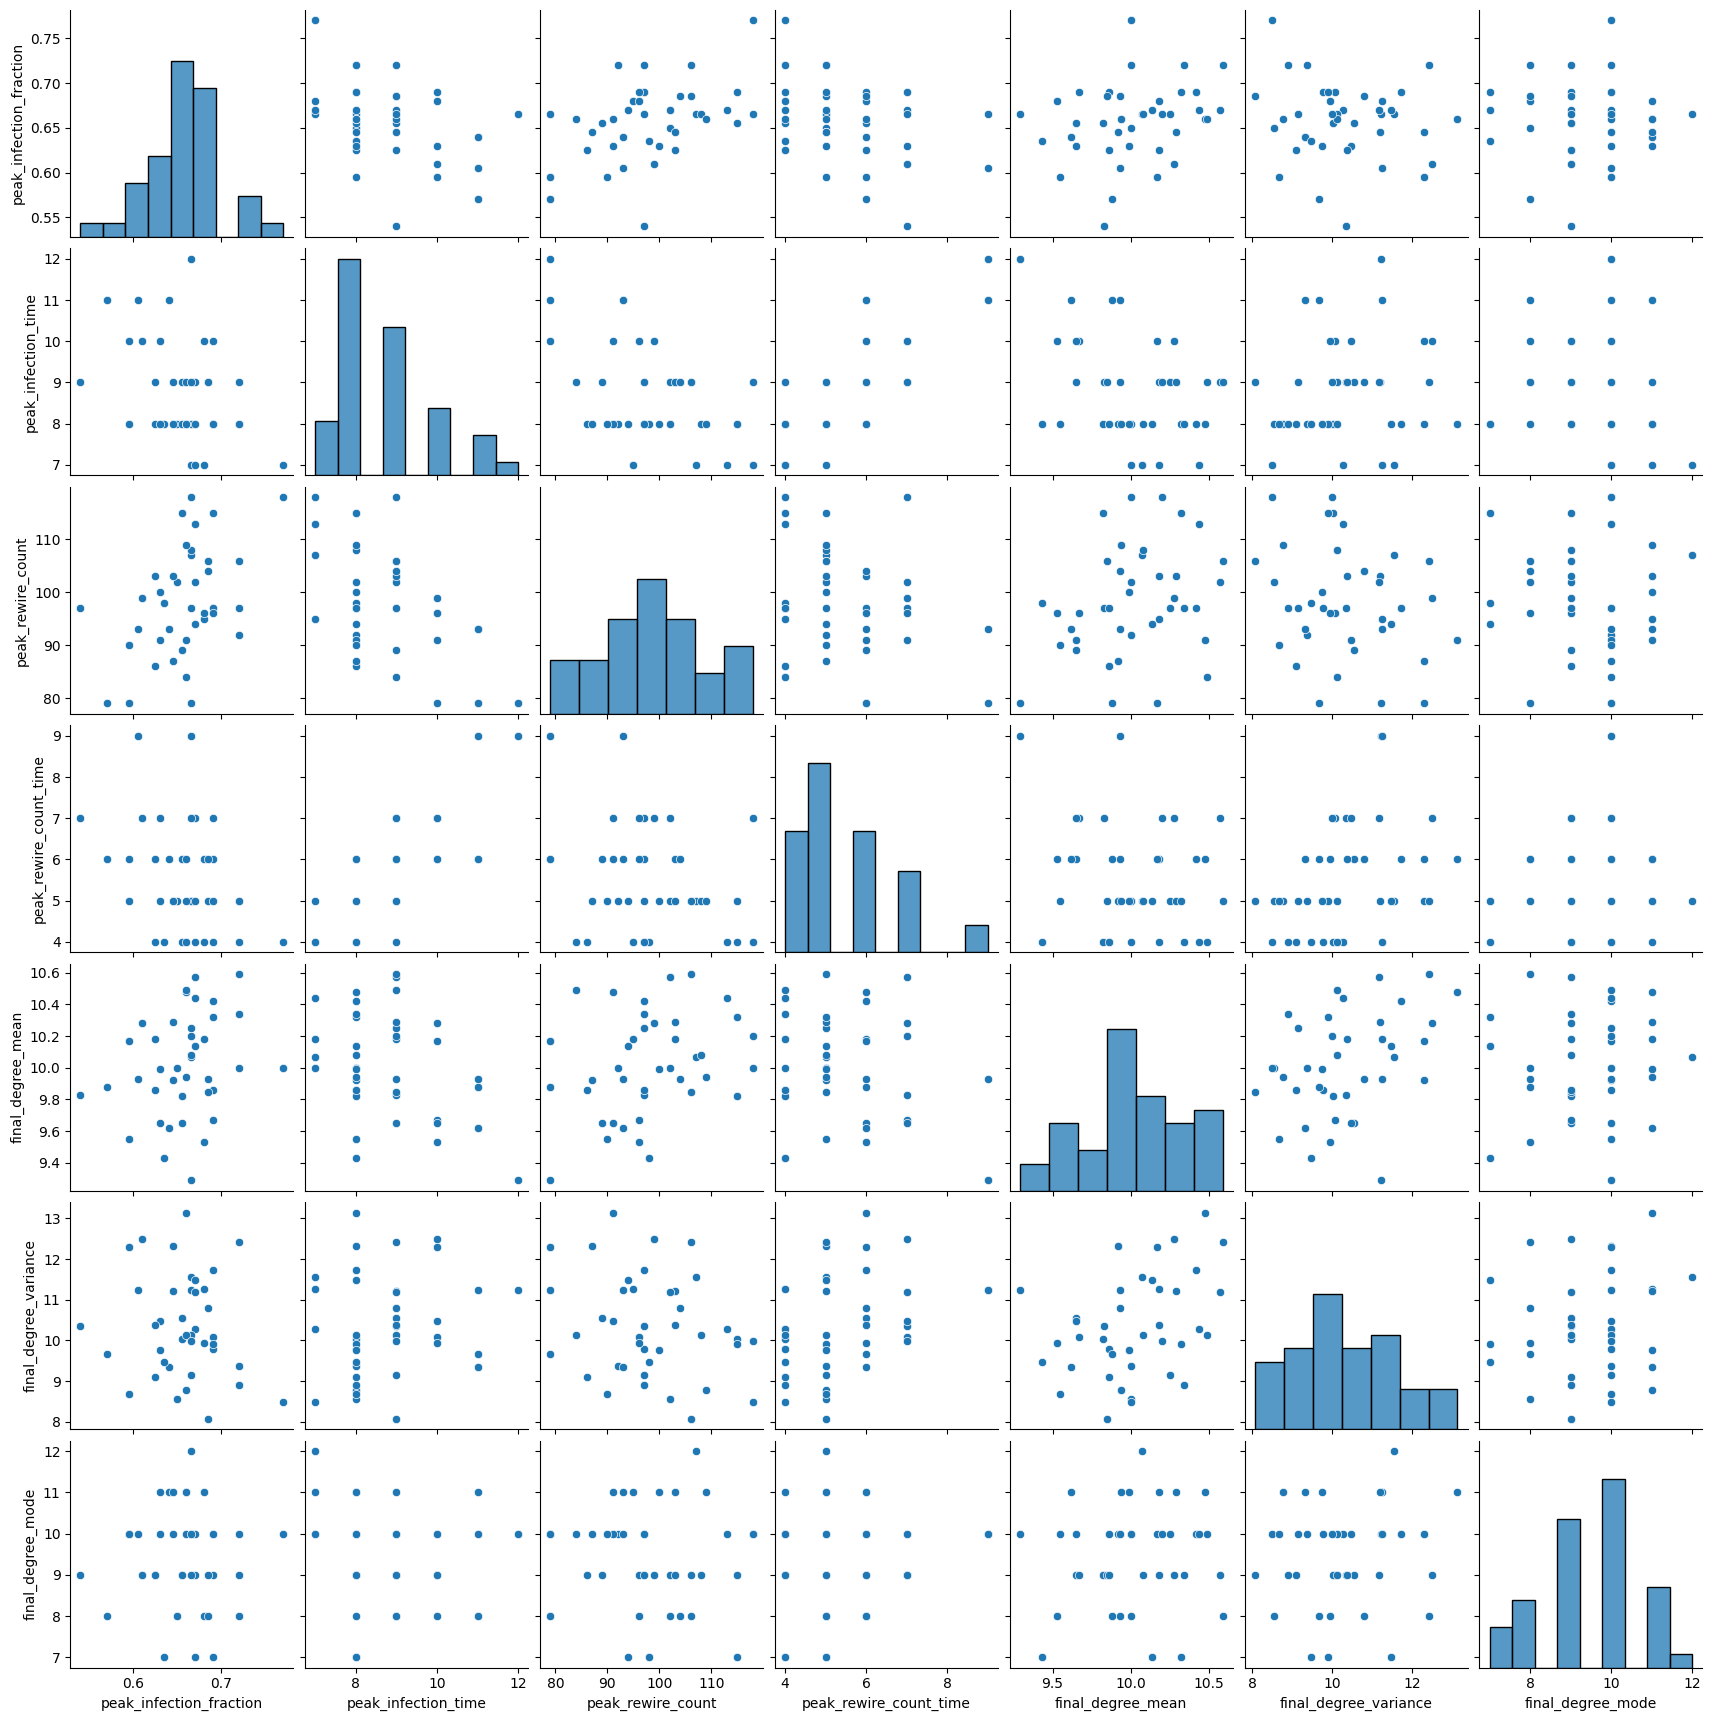

In [57]:
# pairwise scatter plot of the summary statistics
summary_stats = pd.DataFrame({
    'peak_infection_fraction': peak_infection_fractions,
    'peak_infection_time': peak_infection_times,
    'peak_rewire_count': peak_rewire_counts,
    'peak_rewire_count_time': peak_rewire_count_times,
    'final_degree_mean': final_degree_means,
    'final_degree_variance': final_degree_variances,
    'final_degree_mode': final_degree_modes
})

sns.pairplot(summary_stats)

In [ ]:
# save summary statistics observed to csv
# summary_stats.to_csv('data/summary_statistics_observed.csv', index=False)